In [18]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import off.off as off
import off.off_interface as offi
from pathlib import Path

from gpytorch_gp_model import GPyTorchGPSurrogate, HeteroscedasticGPSurrogate, predict_loads_sector_average
import matplotlib.pyplot as plt

# import optimizer
from msr import MSR_optimizer
from msr import ObjFuncComponent
import time

import cProfile
import pstats
import io

profiler = cProfile.Profile()

OFF_PATH = Path(off.OFF_PATH)

# ============================================================================
# Configure and load GPyTorch surrogate model

OUTPUT_NAME = ['TwrBsMyt']  # Change to 'TwrBsMyt' or other sensors
USE_HETEROSCEDASTIC = True  # Set to True to use heteroscedastic model
m_coeff = 4 

if USE_HETEROSCEDASTIC:
    print("Loading pre-trained HETEROSCEDASTIC GPyTorch surrogate")
    model_path = f'C:\\Users\\daanvanderhoek\\Nextcloud\\PostDoc\\Software\\LoadSurrogate\\Surrogate_models\\heteroscedastic_{OUTPUT_NAME[0]}.h5'
    surrogate = HeteroscedasticGPSurrogate.load_h5(model_path)
    model_type = "Heteroscedastic (Input-Dependent Uncertainty)"
else:
    print("Loading pre-trained HOMOSCEDASTIC GPyTorch surrogate")
    model_path = f'C:\\Users\\daanvanderhoek\\Nextcloud\\PostDoc\\Software\\LoadSurrogate\\Surrogate_models\\gpytorch_surrogate_{OUTPUT_NAME[0]}.h5'
    surrogate = GPyTorchGPSurrogate.load_h5(model_path)
    model_type = "Homoscedastic (Constant Uncertainty)"

Loading pre-trained HETEROSCEDASTIC GPyTorch surrogate


Processing run: receding_horizon_3turbs_TwrBsMyt_w0.10
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.20
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.30
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.50
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.70
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.80
Processing run: receding_horizon_3turbs_TwrBsMyt_w0.90


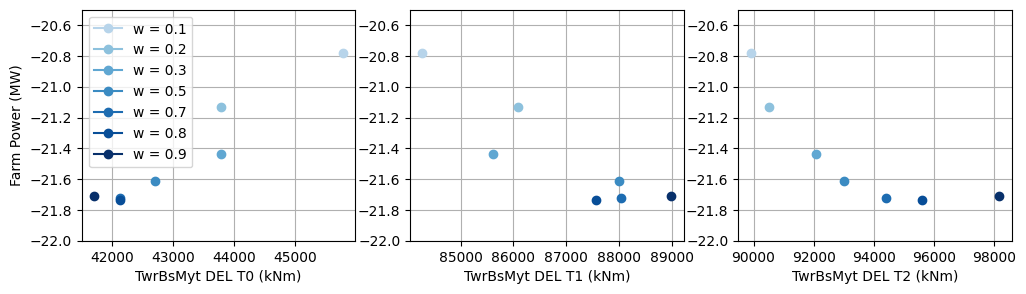

In [19]:
# Look for directories in .\runs with the name pattern 'receding_horizon_3turbs_TwrBsMyt_w*'
run_dirs = [d for d in os.listdir(f'{OFF_PATH}/runs') if d.startswith('receding_horizon_3turbs_TwrBsMyt_w')]

# Plotting the results in two subplots, one for each turbine
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

# Use blue color gradient increasing in intensity with weight
colors = plt.cm.Blues(np.linspace(0.3, 1, len(run_dirs)))

# Loop through each run directory and plot the results
for run_dir in run_dirs:
    run_path = os.path.join(f'{OFF_PATH}/runs', run_dir)
    print(f"Processing run: {run_dir}")
    
    # Extract weight from the directory name
    weight_str = run_dir.split('_')[-1]  # Get the last part after the last underscore without the 'w' prefix
    try:
        weight = float(weight_str[1:])  # Convert to float after removing the 'w' prefix
    except ValueError:
        print(f"Invalid weight format in directory name: {run_dir}. Skipping this run.")
        continue

    # Load the results from the run directory
    results_file = os.path.join(run_path, 'measurements.csv')
    if not os.path.exists(results_file):
        print(f"Results file not found in {run_path}. Skipping this run.")
        continue
    control_file = os.path.join(run_path, 'applied_control.csv')

    df_meas = pd.read_csv(results_file)

    ws_cols = ['WS_sec_up_PyWake', 'WS_sec_right_PyWake', 'WS_sec_down_PyWake', 'WS_sec_left_PyWake']
    ti_cols  = ['TI_sec_up_PyWake',  'TI_sec_right_PyWake',  'TI_sec_down_PyWake',  'TI_sec_left_PyWake']
    sectors  = ['up', 'right', 'down', 'left']

    n_wt = int(df_meas['t_idx'].nunique())
    n_time = int(len(df_meas) / n_wt)
    sector_data = np.zeros((n_wt, n_time, len(sectors), 2))  # (wt, time, sector, quantity=[WS, TI])
    power_data = np.zeros((n_wt, n_time))  # (wt, time)
    for wt_i in range(n_wt):
        wt_df = df_meas[df_meas['t_idx'] == wt_i]
        sector_data[wt_i, :, :, 0] = wt_df[ws_cols].values
        sector_data[wt_i, :, :, 1] = wt_df[ti_cols].values
        power_data[wt_i, :] = wt_df['Power_PyWake'].values

    farm_power = np.sum(np.mean(power_data, axis=1), axis=0)/1e6

    time_coords = df_meas[df_meas['t_idx'] == 0]['time'].values
    sector_avg = xr.DataArray(
        sector_data,
        dims=['wt', 'time', 'sector', 'quantity'],
        coords={'wt': list(range(n_wt)), 'time': time_coords, 'sector': sectors}
    ).expand_dims({'wd': 1, 'ws': 1})

    # Read yaw angles from applied_control.csv
    df_ctrl = pd.read_csv(control_file)

    yaw_angles = np.zeros((n_wt, n_time))
    for wt_i in range(n_wt):
        yaw_angles[wt_i, :] = df_ctrl[df_ctrl['t_idx'] == wt_i]['yaw'].values

    helix_amplitudes = np.zeros((n_wt, n_time))

    # Infer reference turbine loads based on inflow from sector_avg using the surrogate model
    surrogates_dict = {OUTPUT_NAME[0]: surrogate}
    loads_xr = predict_loads_sector_average(
        surrogates_dict, 
        sector_avg, 
        yaw_angles, 
        helix_amplitudes,
        return_std=False
    )

    # Average DELs following miner's rule for all turbines
    loads_avg = [
        (np.mean(loads_xr.sel(wt=wt_i, name=OUTPUT_NAME[0]).values.squeeze() ** m_coeff)) ** (1 / m_coeff)
        for wt_i in range(n_wt)
    ]
    
    ax[0].plot(loads_avg[0], -farm_power, 'o-', color=colors[run_dirs.index(run_dir)], label=f'w = {weight}')
    ax[1].plot(loads_avg[1], -farm_power, 'o-', color=colors[run_dirs.index(run_dir)], label=f'w = {weight}')
    ax[2].plot(loads_avg[2], -farm_power, 'o-', color=colors[run_dirs.index(run_dir)], label=f'w = {weight}')

# Figure labels    
ax[0].set_xlabel(f'{OUTPUT_NAME[0]} DEL T0 (kNm)')
ax[1].set_xlabel(f'{OUTPUT_NAME[0]} DEL T1 (kNm)')
ax[2].set_xlabel(f'{OUTPUT_NAME[0]} DEL T2 (kNm)')
ax[0].set_ylabel('Farm Power (MW)')
ax[0].set_ylim(-22, -20.5)
ax[1].set_ylim(-22, -20.5)
ax[2].set_ylim(-22, -20.5)
# ax[0].set_xlim(40e3, 50e3)
# ax[1].set_xlim(77e3, 87e3)
# ax[2].set_xlim(40e3, 50e3)
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[0].legend()

plt.show()
# Save the plot
plot_file = os.path.join(OFF_PATH, '03_Code', f'3turbs_pareto_{OUTPUT_NAME[0]}.png')
fig.savefig(plot_file, dpi=300, bbox_inches='tight')
